<a href="https://colab.research.google.com/github/Sadiya8924/Kuis-PBO/blob/main/Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

Mounted at /content/drive


In [2]:
def convolution2d(image, kernel, stride=1, padding=0):
    padded_image = np.pad(image, pad_width=padding, mode='constant', constant_values=0)
    image_height, image_width = padded_image.shape
    kernel_height, kernel_width = kernel.shape
    output_height = (image_height - kernel_height) // stride + 1
    output_width = (image_width - kernel_width) // stride + 1
    output = np.zeros((output_height, output_width))
    for y in range(0, output_height):
        for x in range(0, output_width):
            y_start = y * stride
            y_end = y_start + kernel_height
            x_start = x * stride
            x_end = x_start + kernel_width
            roi = padded_image[y_start:y_end, x_start:x_end]
            convolution_sum = np.sum(roi * kernel)
            output[y, x] = convolution_sum
    return output

In [4]:
img_path = '/content/drive/MyDrive/PCVK25_GANJIL_24/IMG/mandrill.tiff'
img = cv.imread(img_path)
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

In [5]:
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])

Citra Asli


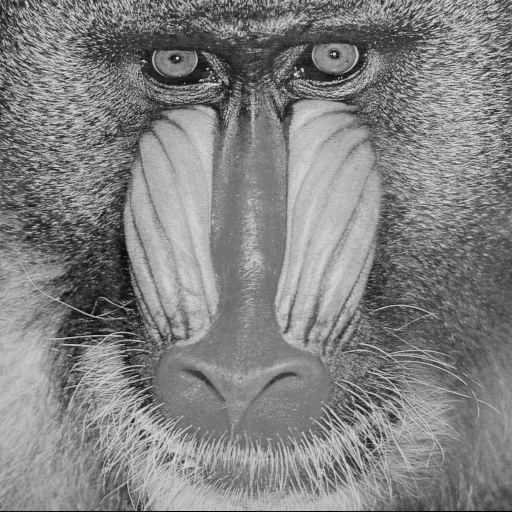


Hasil Sharpening


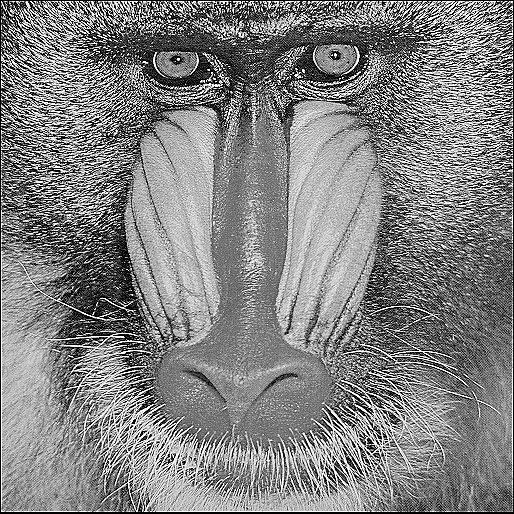

In [8]:
sharpened_image = convolution2d(img_gray, kernel_sharpen, 1, 2)

print("Citra Asli")
cv2_imshow(img_gray)

print("\nHasil Sharpening")
cv2_imshow(sharpened_image)


Citra Asli


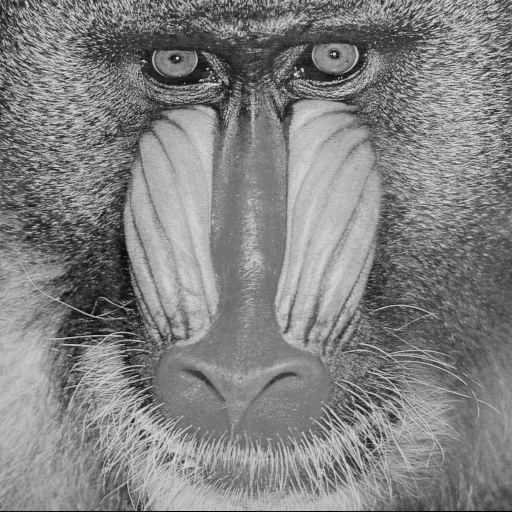


Hasil Sharpening


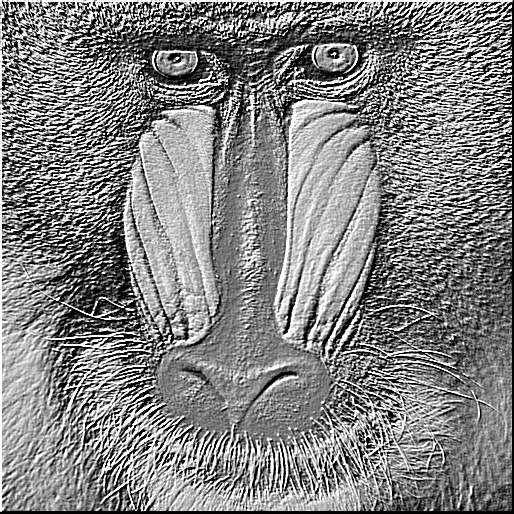

In [9]:
kernel_emboss = np.array([[-2, -1, 0],
                          [-1,  1, 1],
                          [ 0,  1, 2]])

hasil_emboss = convolution2d(img_gray, kernel_emboss, 1, 2)
print("\nCitra Asli")
cv2_imshow(img_gray)
print("\nHasil Sharpening")
cv2_imshow(hasil_emboss)


Citra Asli


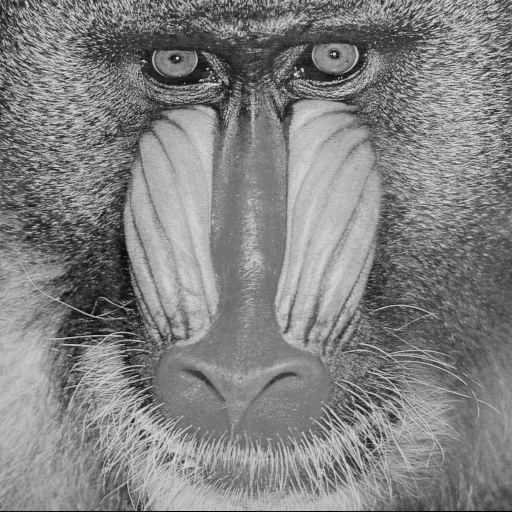


Hasil Left Sobel Edge Detection


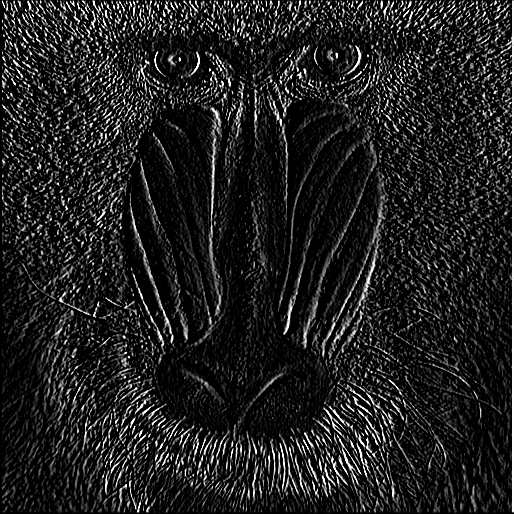

In [11]:
kernel_LeftSobelEdgeDetection = np.array([[1, 0, -1],
                                          [2,  0, -2],
                                          [ 1,  0, -1]])

hasil_LeftSobelEdgeDetection = convolution2d(img_gray, kernel_LeftSobelEdgeDetection, 1, 2)
print("\nCitra Asli")
cv2_imshow(img_gray)
print("\nHasil Left Sobel Edge Detection")
cv2_imshow(hasil_LeftSobelEdgeDetection)


Citra Asli


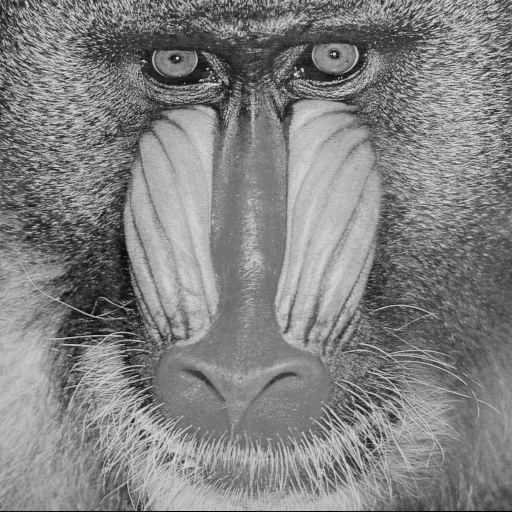


Hasil Canny Edge Detection


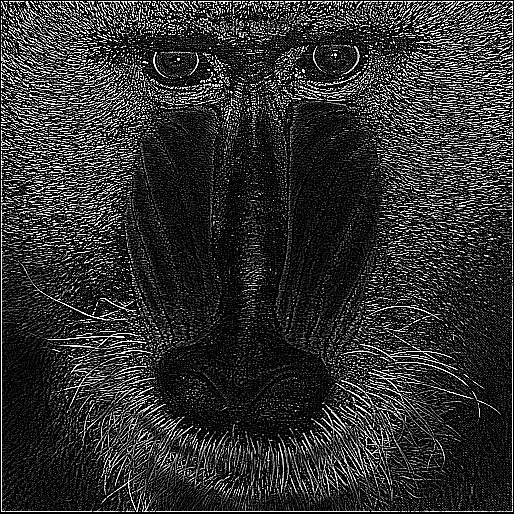

In [12]:
kernel_CannyEdgeDetection = np.array([[-1, -1, -1],
                                      [-1,  8, -1],
                                      [-1,  -1, -1]])

hasil_CannyEdgeDetection = convolution2d(img_gray, kernel_CannyEdgeDetection, 1, 2)
print("\nCitra Asli")
cv2_imshow(img_gray)
print("\nHasil Canny Edge Detection")
cv2_imshow(hasil_CannyEdgeDetection)

Citra Asli


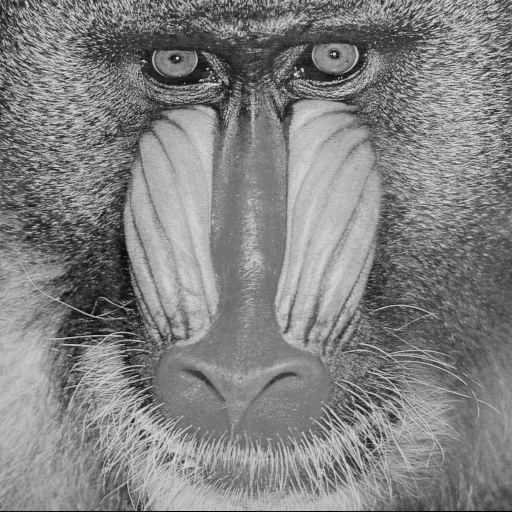

Hasil 21x21 Gaussian Blur


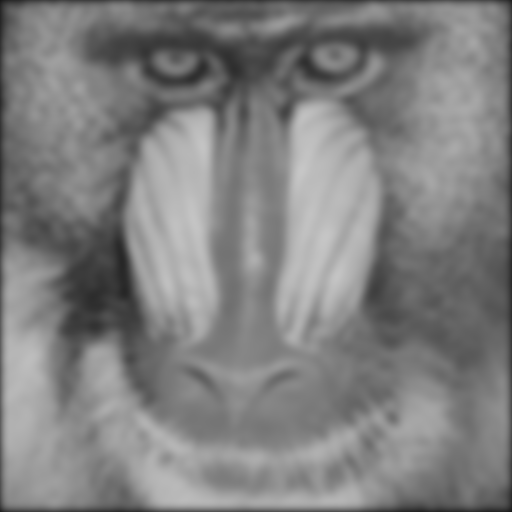

In [13]:
kernel_size = 21

sigma = math.sqrt(kernel_size)

gaussian_kernel_1d = cv.getGaussianKernel(kernel_size, sigma)

gauss_kernel_2d = gaussian_kernel_1d @ gaussian_kernel_1d.transpose()

gaussian_blur_image = convolution2d(img_gray, gauss_kernel_2d, stride=1, padding=10)

print("Citra Asli")
cv2_imshow(img_gray)
print("Hasil 21x21 Gaussian Blur")
cv2_imshow(gaussian_blur_image)